# Plotting distributions of segmented cell parameters
This script created two figures:
1. Rescaled distributions of height, area, volume and apsect ratio. The data is rescaled by the mean value in each frame.
2. The standard deviation of the distribution plotted against the mean value

In [1]:
# Imports
import sys
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

from cmcrameri import cm
from scipy.stats import linregress
from scipy.optimize import curve_fit

sys.path.append("scripts/utils/")
from SegmentedCells      import SegmentedCells
from averaging_functions import bin_distribution, compute_pdf_from_bins #, compute_derivative_of_cdf

savefig   = False
data_path = "../../../../hdd_data/silja/Monolayers/"

In [2]:
# Set font style
plt.rcParams["pdf.use14corefonts"] = True

font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 14}

mpl.rc('font', **font)

In [3]:
# Load data
dataset = "MDCK_20240301_B1-4"

### Set plot parameters

In [4]:
density_binsize = 100  # size of density bin to bin distributions by
scale_factor = 25      # scale factor for binning of pdf
sigma_smooth = 2       # size of smoothin kernel for pdf

h_cmap = mpl.colormaps["Blues_r"]
A_cmap = mpl.colormaps["Oranges_r"]
V_cmap = mpl.colormaps["Greens_r"]
par_cmap = mpl.colormaps["Purples_r"]
var_cmap = mpl.colormaps["Reds_r"]

In [5]:
cells = SegmentedCells(f"{data_path}cell_features/raw/{dataset}_cells.p")

h_data = cells.h[:-6]
A_data = cells.A[:-6]
V_data = h_data * A_data
planar_aspect_ratio_data = cells.amajor[:-6] / cells.aminor[:-6]
vertical_aspect_ratio_data = h_data / np.sqrt(A_data)
density = cells.density[:-6]
par_data = planar_aspect_ratio_data
var_data = vertical_aspect_ratio_data

State loaded from ../../../../hdd_data/silja/Monolayers/cell_features/raw/MDCK_20240301_B1-4_cells.p.


### Bin distributions by cell density in monolayer

In [6]:
# Define density binnong edges
min_density = 100 * int(min(density) / 100)
max_density = 100 * int(max(density) / 100)
bin_edges = np.arange(min_density, max_density + density_binsize, density_binsize)

h_binned_distribution   = bin_distribution(h_data,   density, bin_edges)
A_binned_distribution   = bin_distribution(A_data,   density, bin_edges)
V_binned_distribution   = bin_distribution(V_data,   density, bin_edges)
par_binned_distribution = bin_distribution(par_data, density, bin_edges)
var_binned_distribution = bin_distribution(var_data, density, bin_edges)

### Compute PDF

In [7]:
hx_pdf,   hy_pdf   = [], []
Ax_pdf,   Ay_pdf   = [], []
Vx_pdf,   Vy_pdf   = [], []
parx_pdf, pary_pdf = [], []
varx_pdf, vary_pdf = [], []

for h, A, V, par, var in zip(h_binned_distribution,
                             A_binned_distribution,
                             V_binned_distribution, 
                             par_binned_distribution, 
                             var_binned_distribution):
    
    # rescale bin by mean value in bin
    h_rescaled_bin   = h / np.mean(h)
    A_rescaled_bin   = A / np.mean(A)
    V_rescaled_bin   = V / np.mean(V)
    par_rescaled_bin = par / np.mean(par)
    var_rescaled_bin = var / np.mean(var)

    hx,   hy   = compute_pdf_from_bins(h_rescaled_bin,   scale_factor, sigma=sigma_smooth)
    Ax,   Ay   = compute_pdf_from_bins(A_rescaled_bin,   scale_factor, sigma=sigma_smooth)
    Vx,   Vy   = compute_pdf_from_bins(V_rescaled_bin,   scale_factor, sigma=sigma_smooth)
    parx, pary = compute_pdf_from_bins(par_rescaled_bin, scale_factor, sigma=sigma_smooth)
    varx, vary = compute_pdf_from_bins(var_rescaled_bin, scale_factor, sigma=sigma_smooth)

    hx_pdf.append(hx),     hy_pdf.append(hy)
    Ax_pdf.append(Ax),     Ay_pdf.append(Ay)
    Vx_pdf.append(Vx),     Vy_pdf.append(Vy)
    parx_pdf.append(parx), pary_pdf.append(pary)
    varx_pdf.append(varx), vary_pdf.append(vary)


### Compute standard deviation and mean

In [8]:
def linear(x, a):
    return a*x

means  = []
stds   = []
x_fits = []
y_fits = []
for data in [h_data, A_data, V_data, par_data, var_data]:
    mean, std   = np.ma.mean(data, axis=1),   np.ma.std(data, axis=1)
    param, popt = curve_fit(linear, mean, std)
    print(f"{param[0]:0.6f} +/- {popt[0][0]:0.6f}")
    
    means.append(mean)
    stds.append(std)
    x_fits.append(np.linspace(mean.min(), mean.max(), 100))
    y_fits.append(param * x_fits[-1])

# # taking average over 1 h
# dt = 12
# N = int(len(mean) / dt)
# x_plot = np.array(mean)[:N*dt].reshape(N, dt).mean(axis=1)
# y_plot = np.array(std)[:N*dt].reshape(N, dt).mean(axis=1)
# y_err  = np.array(std)[:N*dt].reshape(N, dt).mean(axis=1) / dt

0.211142 +/- 0.000003
0.330147 +/- 0.000004
0.306550 +/- 0.000004
0.189743 +/- 0.000002
0.336091 +/- 0.000007


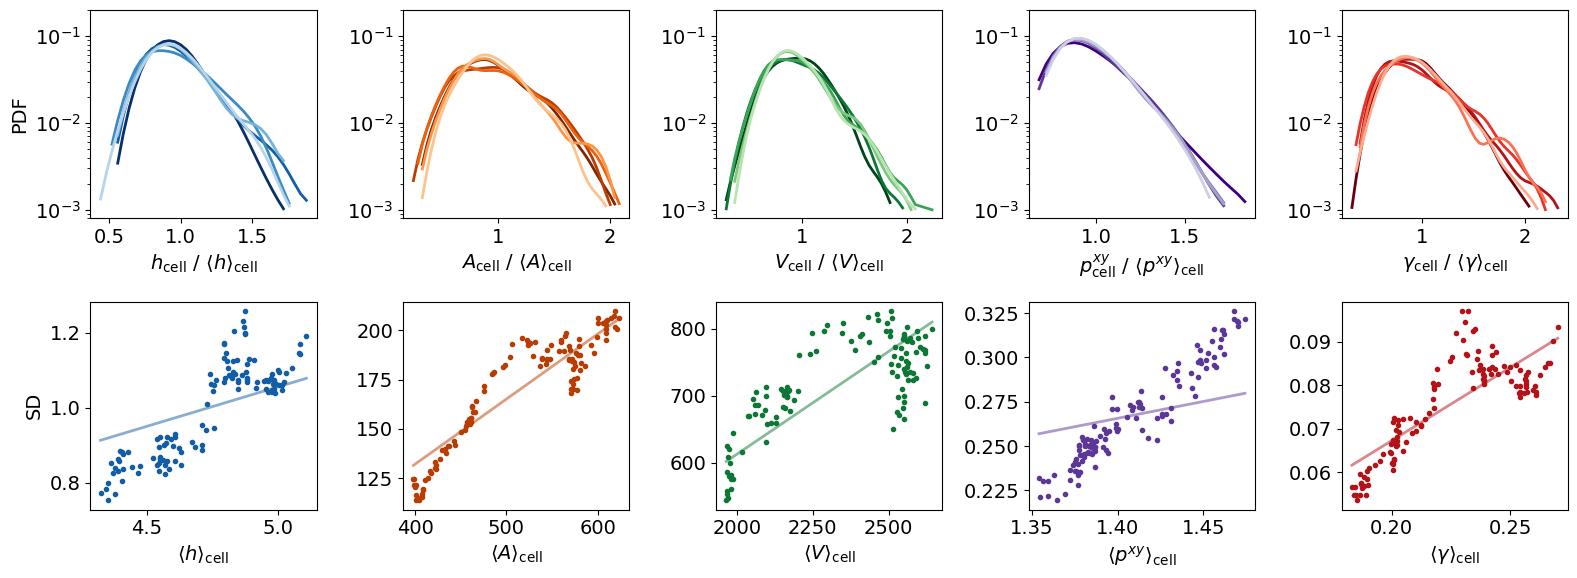

In [ ]:
# Plot
h_colors   = h_cmap(np.linspace(0, 0.7, len(hx_pdf)))
A_colors   = A_cmap(np.linspace(0, 0.7, len(Ax_pdf)))
V_colors   = V_cmap(np.linspace(0, 0.7, len(Vx_pdf)))
par_colors = par_cmap(np.linspace(0, 0.7, len(parx_pdf)))
var_colors = var_cmap(np.linspace(0, 0.7, len(varx_pdf)))


x_pdfs = [hx_pdf, Ax_pdf, Vx_pdf, parx_pdf, varx_pdf]
y_pdfs = [hy_pdf, Ay_pdf, Vy_pdf, pary_pdf, vary_pdf]
colors = [h_colors, A_colors, V_colors, par_colors, var_colors]
labels = ["h", "A", "V", "p^{{xy}}", "\gamma"]

fig, axes = plt.subplots(2, 5, figsize=(16,6))

for ax, x_pdf, y_pdf, x_fit, y_fit, mean, std, c, l in zip(axes.T,
                                                           x_pdfs,
                                                           y_pdfs,
                                                           x_fits,
                                                           y_fits,
                                                           means,
                                                           stds,
                                                           colors,
                                                           labels):
    
    for i in range(0, len(x_pdf), 2):
        mask = y_pdf[i] > 1e-3
        ax[0].plot(x_pdf[i][mask], y_pdf[i][mask], '-', c=c[i], lw=2)
    
    ax[1].plot(x_fit, y_fit, '-', c=c[2], lw=2, alpha=0.5)
    ax[1].plot(mean, std, '.', c=c[2])

    ax[0].set(xlabel=rf"${l}_{{\text{{cell}}}} ~/~\langle {l} \rangle_{{\text{{cell}}}}$",
              yscale="log",
              ylim=(8e-4, 2e-1))
    ax[1].set(xlabel=rf"$\langle {l} \rangle_{{\text{{cell}}}}$")

axes[0,0].set(ylabel="PDF")
axes[1,0].set(ylabel="SD")

fig.tight_layout()
fig.savefig(f"figs/Elife/cellwise_distribution.svg")